In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

!pip install tensorflow

In [ ]:
file_path = '/content/makam.xlsx'
df = pd.read_excel(file_path)

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),TDS\n(mg/L),Salinity\n(g/L),DO\n(mg/L),Sensor Depth\n(m),pH,Chlorophyll\n(ug/L),Turbid\n(NTU)
0,2014-04-28 14:40:00,28.93,0.0,20.0,0.01,7.87,0.96,9.34,1.10,4.50
1,2014-04-28 14:50:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-04-28 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-04-28 15:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-04-28 15:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.72,260.0,166.5,0.12,3.27,2.02,0.00,6.70,49.64
538749,2024-07-25 22:10:00,30.71,260.0,166.4,0.12,3.35,2.06,0.00,5.86,40.77
538750,2024-07-25 22:20:00,30.71,258.0,165.5,0.12,3.24,2.10,0.00,2.97,55.74
538751,2024-07-25 22:30:00,30.71,258.0,165.3,0.12,3.30,2.13,0.00,5.18,47.67


In [ ]:
df = df.drop(['TDS\n(mg/L)'], axis=1)
df = df.drop(['Salinity\n(g/L)'], axis=1)
df = df.drop(['Sensor Depth\n(m)'], axis=1)
df = df.drop(['Chlorophyll\n(ug/L)'], axis=1)
df = df.drop(['Turbid\n(NTU)'], axis=1)

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
0,2014-04-28 14:40:00,28.93,0.0,7.87,9.34
1,2014-04-28 14:50:00,NaN,NaN,NaN,NaN
2,2014-04-28 15:00:00,NaN,NaN,NaN,NaN
3,2014-04-28 15:10:00,NaN,NaN,NaN,NaN
4,2014-04-28 15:20:00,NaN,NaN,NaN,NaN
...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.72,260.0,3.27,0.00
538749,2024-07-25 22:10:00,30.71,260.0,3.35,0.00
538750,2024-07-25 22:20:00,30.71,258.0,3.24,0.00
538751,2024-07-25 22:30:00,30.71,258.0,3.30,0.00


In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,432899.000000,432899.000000,432899.000000,432899.000000
mean,2019-06-12 06:39:59.999998464,-78.213296,349.596384,-210.651016,-398.025160
min,2014-04-28 14:40:00,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,2016-11-18 22:40:00,29.140000,294.000000,1.630000,7.120000
50%,2019-06-12 06:40:00,30.550000,356.000000,2.720000,7.230000
75%,2022-01-02 14:40:00,31.410000,440.000000,3.600000,7.340000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,1037.028654,1173.119092,1445.086492,1972.434922


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),105854
Conductivity\n(uS/cm),105854
DO\n(mg/L),105854
pH,105854


In [ ]:
# ตรวจสอบค่า -9999 ในทุกคอลัมน์
neg9999_counts = (df == -9999).sum()
print(neg9999_counts)

date_time                    0
Temperature\n(֯C)         4679
Conductivity\n(uS/cm)     4658
DO\n(mg/L)                9234
pH                       17531
dtype: int64


In [ ]:
df = df.replace(-9999, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,428220.000000,428241.000000,423665.000000,415368.000000
mean,2019-06-12 06:39:59.999998464,30.187435,462.158614,2.691163,7.193080
min,2014-04-28 14:40:00,0.000000,-3999.000000,0.000000,-26.300000
25%,2016-11-18 22:40:00,29.190000,297.000000,1.730000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.760000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.620000,7.350000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,2.339895,462.215793,1.578567,0.650542


In [ ]:
# ตรวจสอบค่า 0 ในทุกคอลัมน์
zero_counts = (df == 0).sum()
print(zero_counts)

date_time                    0
Temperature\n(֯C)          597
Conductivity\n(uS/cm)     2263
DO\n(mg/L)               42510
pH                        2794
dtype: int64


In [ ]:
df = df.replace(0, np.nan)

In [ ]:
zero_counts = (df == 50.840000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(50.840000, np.nan)

In [ ]:
zero_counts = (df == -26.300000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(-26.300000, np.nan)

In [ ]:
zero_counts = (df == -3999.000000).sum()
print(zero_counts)

date_time                 0
Temperature\n(֯C)         0
Conductivity\n(uS/cm)    87
DO\n(mg/L)                0
pH                        0
dtype: int64


In [ ]:
df = df.replace(-3999.000000, np.nan)

In [ ]:
zero_counts = (df == 99.990000).sum()
print(zero_counts)

date_time                  0
Temperature\n(֯C)        105
Conductivity\n(uS/cm)      0
DO\n(mg/L)                 0
pH                         0
dtype: int64


In [ ]:
df = df.replace(99.990000, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425891.000000,381155.000000,412572.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.525639,2.991307,7.241768
min,2014-04-28 14:40:00,12.830000,1.000000,0.010000,-15.340000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.832389,1.368198,0.256849


In [ ]:
df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
df['pH'][df['pH'] < 1] = np.nan

<ipython-input-22-096c18d0bb55>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
<ipython-input-22-096c18d0bb55>:1: SettingWithCopyWarning: 
A value is trying to be set 

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412556.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.242067
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.834400,1.368198,0.251171


In [ ]:
df['pH'][df['pH'] > 14] = np.nan

<ipython-input-24-796f110e6a72>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pH'][df['pH'] > 14] = np.nan
<ipython-input-24-796f110e6a72>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame



In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412552.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.241943
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.736159,457.834400,1.368198,0.247345


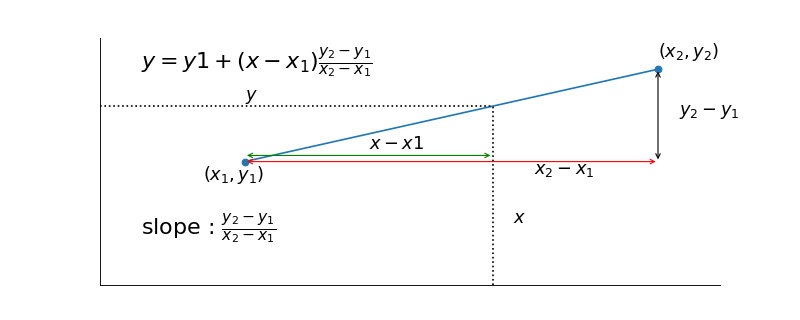

In [ ]:
df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
df['Conductivity\n(uS/cm)'].interpolate(method='linear', inplace=True)
df['DO\n(mg/L)'].interpolate(method='linear', inplace=True)
df['pH'].interpolate(method='linear', inplace=True)

<ipython-input-26-b4db06670e76>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
<ipython-input-26-b4db06670e76>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,536313.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.000000,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,524.967900,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,426.525651,1.217890,0.353856


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),2440
DO\n(mg/L),0
pH,0


In [ ]:
df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)

<ipython-input-29-0624677d0968>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),0
DO\n(mg/L),0
pH,0


In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,538753.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.654009,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,523.263959,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,425.558691,1.217890,0.353856


In [ ]:
# แปลงคอลัมน์ date_time เป็น datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

In [ ]:
df = df.set_index('date_time')

In [ ]:
df = df.resample('D').mean()

In [ ]:
df.describe()

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,3742.000000,3742.000000,3742.000000,3742.000000
mean,30.082841,501.197137,2.964834,7.236713
std,1.604176,359.352210,1.112831,0.345785
min,20.238053,164.506944,0.233403,2.082611
25%,29.155968,318.486111,2.331814,7.160433
50%,30.205885,386.133681,2.907473,7.261844
75%,31.246372,539.541667,3.466858,7.340180
max,34.226458,4057.263889,7.837917,9.276510


# Data

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
date_time,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510
2014-04-29,29.433154,501.199898,7.346309,9.045638
2014-04-30,30.001423,501.199898,6.754846,8.713181
2014-05-01,30.569691,501.199898,6.163383,8.380725
2014-05-02,31.137960,501.199898,5.571919,8.048268
...,...,...,...,...
2024-07-07,31.568542,397.638889,1.674931,5.970347
2024-07-08,31.643167,397.493664,1.762159,6.217419
2024-07-09,31.722251,383.880478,2.868805,4.419900


In [ ]:
def create_dataset(data, look_back=1):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

https://medium.com/datawiz-th/%E0%B8%A1%E0%B8%B2%E0%B8%A5%E0%B8%AD%E0%B8%87-forecast-%E0%B8%A3%E0%B8%B2%E0%B8%84%E0%B8%B2%E0%B8%AB%E0%B8%B8%E0%B9%89%E0%B8%99%E0%B9%81%E0%B8%9A%E0%B8%9A%E0%B8%87%E0%B9%88%E0%B8%B2%E0%B8%A2%E0%B9%86-%E0%B8%94%E0%B9%89%E0%B8%A7%E0%B8%A2-deep-learning-lstm-python-305c480db223

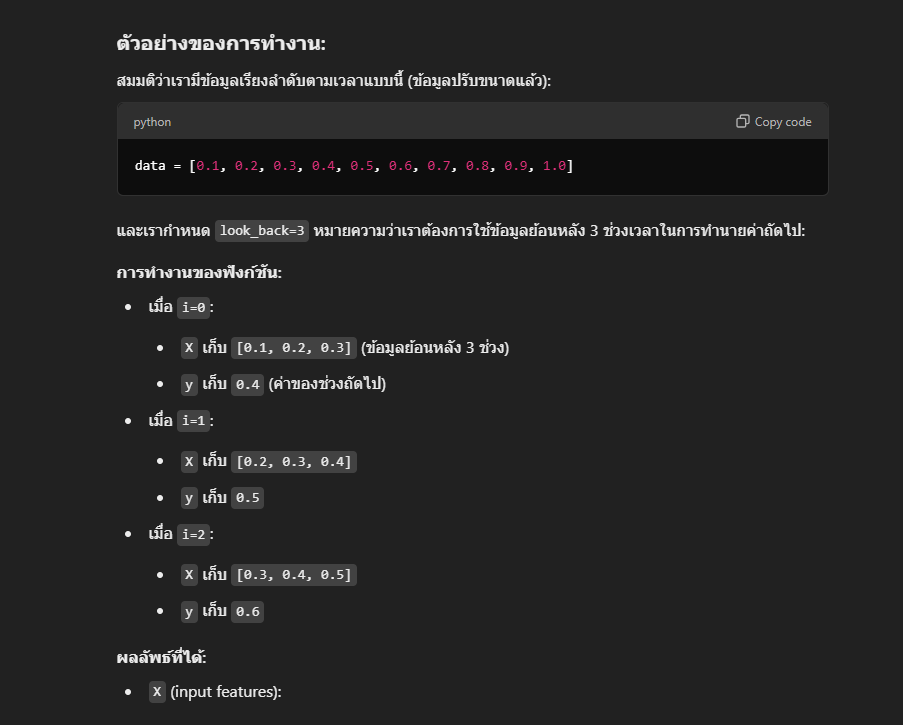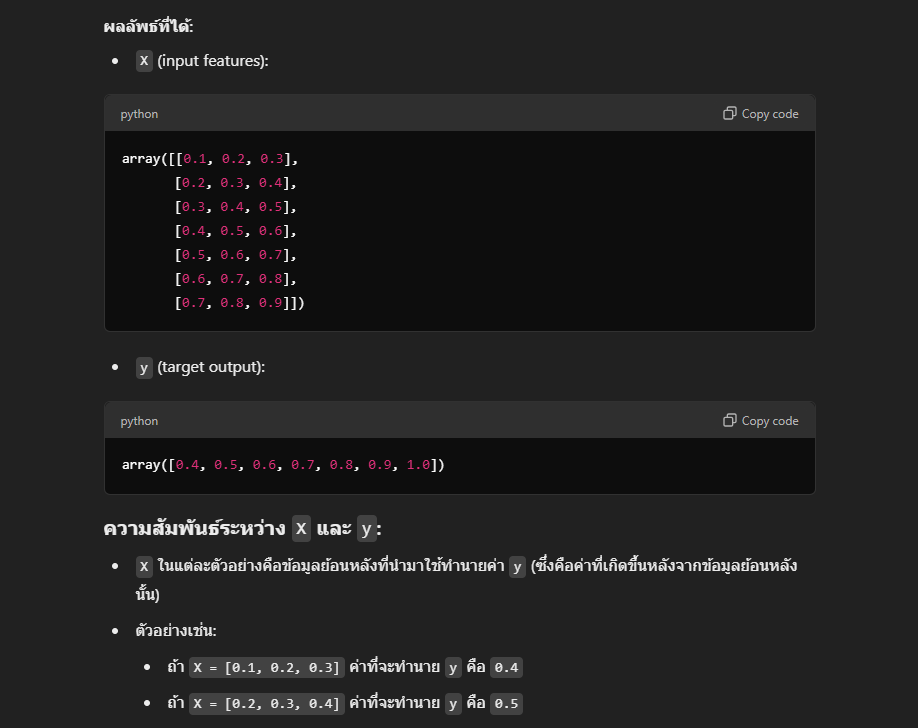

In [ ]:
df[:10]

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
date_time,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510
2014-04-29,29.433154,501.199898,7.346309,9.045638
2014-04-30,30.001423,501.199898,6.754846,8.713181
2014-05-01,30.569691,501.199898,6.163383,8.380725
2014-05-02,31.137960,501.199898,5.571919,8.048268
2014-05-03,31.678415,501.199898,4.928164,7.711670
2014-05-04,31.693750,501.199898,4.448542,7.597917
2014-05-05,31.747917,501.199898,4.301528,7.620000
2014-05-06,31.799965,501.199898,4.414688,7.693785


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Temperature\n(֯C)']])

In [ ]:
look_back = 7 #ย้อนหลัง 7 วันมาเทรนข้อมูล
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (3735, 7, 1)
Shape of y: (3735,)


In [ ]:
print("X:")
print(X[:5])
# แสดงค่า y แถวแรก 5 แถว
print("\n y:")
print(y[:5])

X:
[[[0.62912608]
  [0.65733737]
  [0.69796161]
  [0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]]

 [[0.65733737]
  [0.69796161]
  [0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]]

 [[0.69796161]
  [0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]
  [0.82653541]]

 [[0.73858586]
  [0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]
  [0.82653541]
  [0.82480531]]

 [[0.77921011]
  [0.81784608]
  [0.81894232]
  [0.82281457]
  [0.82653541]
  [0.82480531]
  [0.83715681]]]

 y:
[0.82281457 0.82653541 0.82480531 0.83715681 0.84707574]


### GRU (Gated Recurrent Unit)

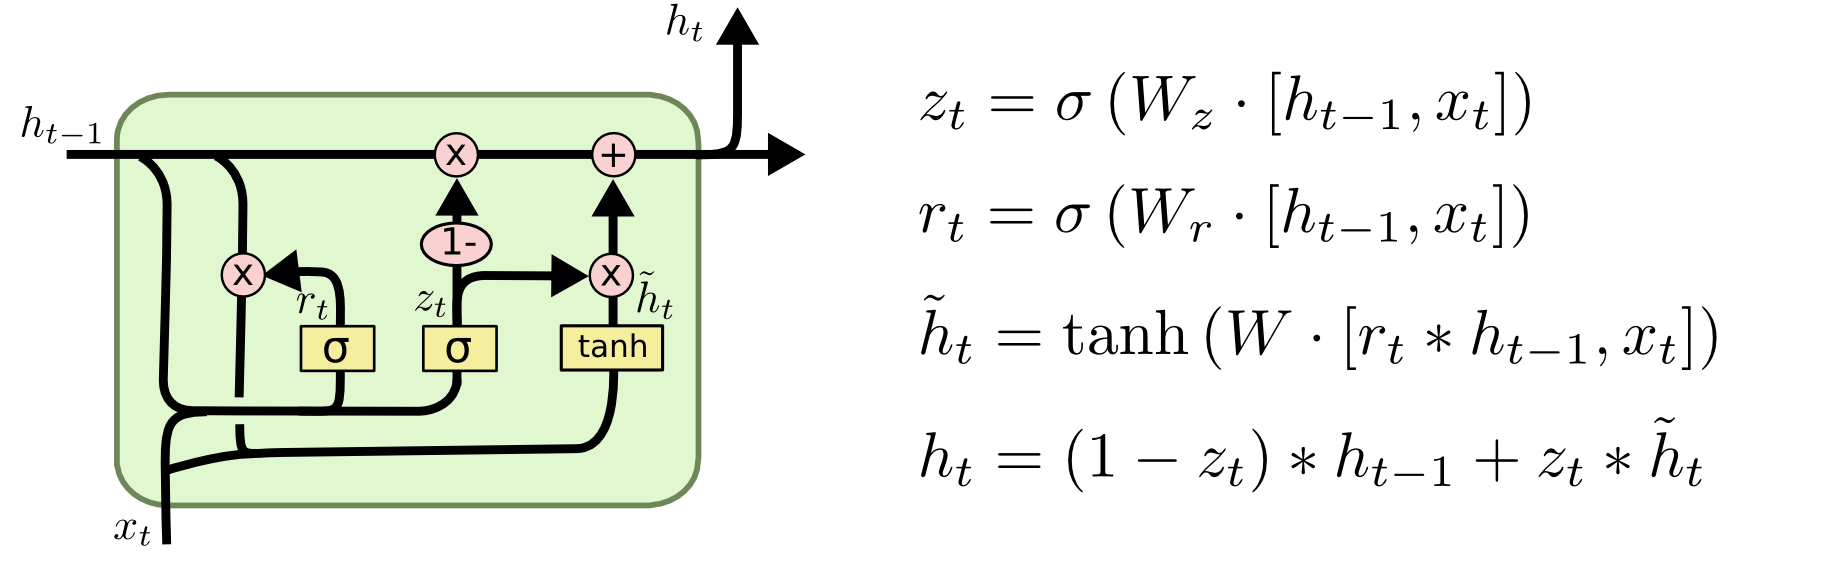

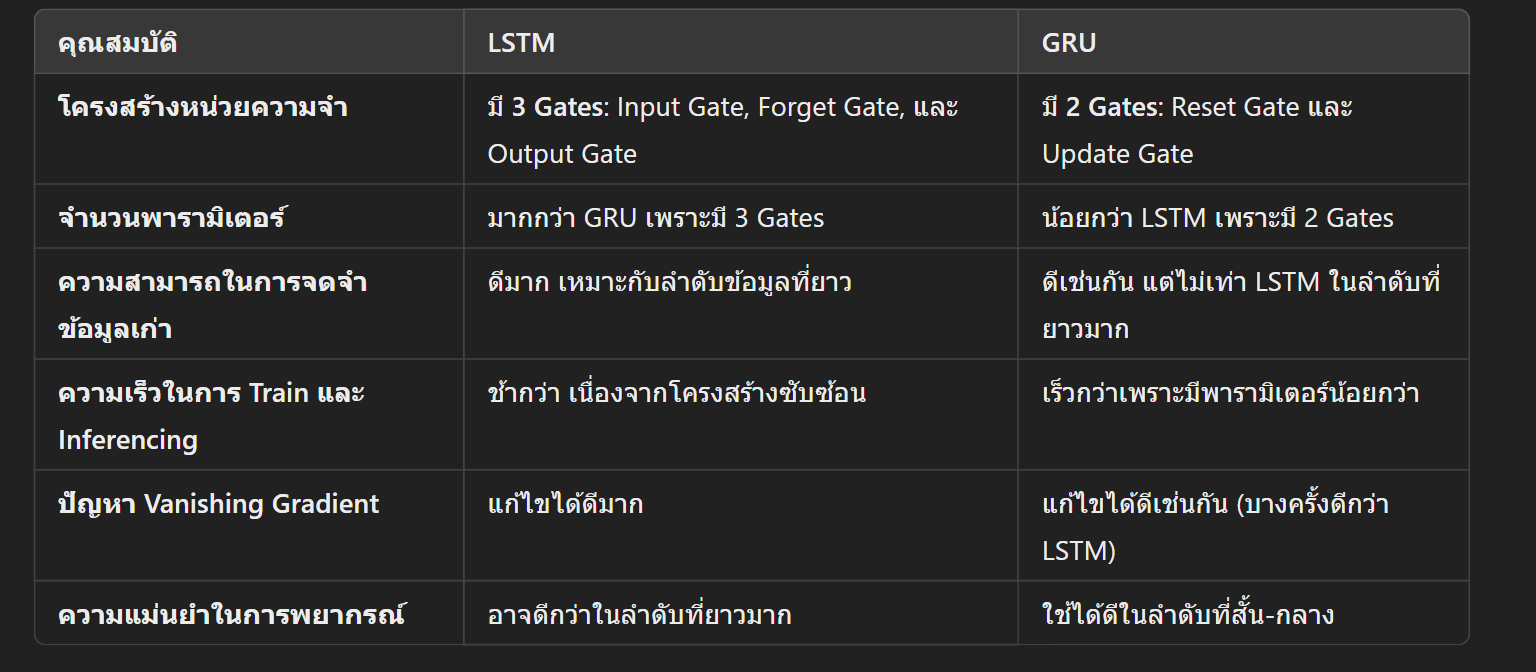

In [ ]:
def train_and_evaluate_gru(X_train, y_train, X_test, y_test, look_back, epochs=20, batch_size=16):
    model = Sequential()

    # GRU Layer 1
    model.add(GRU(50, return_sequences=True, input_shape=(look_back, 1),
                  kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())

    # GRU Layer 2
    model.add(GRU(50, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.4))

    # Dense Layers
    model.add(Dense(20, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1))

    # Compile Model
    optimizer = RMSprop(learning_rate=0.0005)
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Early Stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train Model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop])

    # Plot Training Loss
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    # Predict
    predictions = model.predict(X_test)

    # Calculate Metrics
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")

    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics


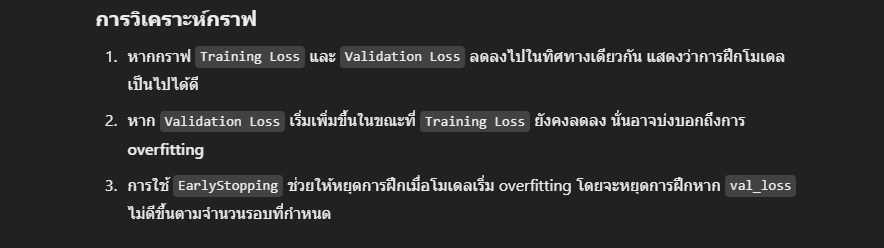

In [ ]:
def split_and_train_gru(X, y, look_back, num_splits=3, epochs=20, batch_size=16):
    split_size = int(len(X) * 0.7)
    split_increment = int((len(X) - split_size) / num_splits)
    models = []
    metrics_list = []


    for i in range(num_splits):
        split_at = split_size + i * split_increment


        X_train = X[i * split_increment:split_at]
        X_test  = np.concatenate((X[:i * split_increment], X[split_at:]), axis=0)
        y_train = y[i * split_increment:split_at]
        y_test  = np.concatenate((y[:i * split_increment], y[split_at:]), axis=0)

        print(f"\n--- Training round {i+1} ---")
        print(f"Training data size: {X_train.shape}, Testing data size: {X_test.shape}")


        model, predictions, metrics = train_and_evaluate_gru(X_train, y_train, X_test, y_test, look_back, epochs=epochs, batch_size=batch_size)


        models.append(model)
        metrics_list.append(metrics)

    return models, metrics_list


#**Temp**


--- Training round 1 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2802 - val_loss: 0.2069
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1079 - val_loss: 0.1336
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0748 - val_loss: 0.0728
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0585 - val_loss: 0.0622
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0447 - val_loss: 0.0434
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0359 - val_loss: 0.0312
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0279 - val_loss: 0.0202
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0217 - val_loss: 0.0142
Epoch 9/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0176 - val_loss: 0.0144
Epoch 10/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0147 - val_loss: 0.0110
Epoch 11/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0116 - val_loss: 0.0080
Epoch 12/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss:

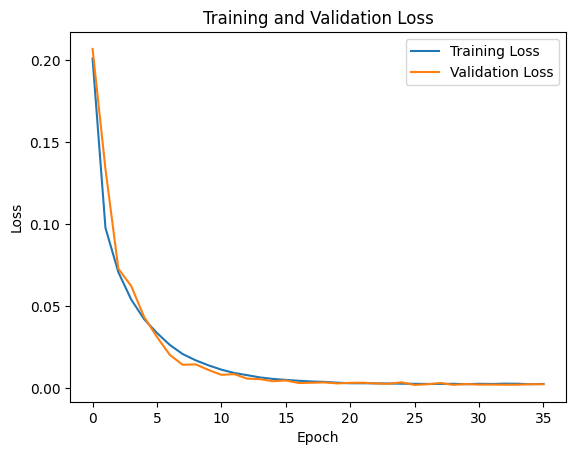

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R2: 0.9090065457814075
MAE: 0.020361298565230557
RMSE: 0.03964358574091544
MSE: 0.0015716138903973142

--- Training round 2 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.4060 - val_loss: 0.2440
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1196 - val_loss: 0.1661
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0888 - val_loss: 0.0848
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0661 - val_loss: 0.0444
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0521 - val_loss: 0.0334
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0413 - val_loss: 0.0313
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0343 - val_loss: 0.0266
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0274 - val_loss: 0.0184
Epoch 9/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0225 - val_loss: 0.0154
Epoch 10/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0188 - val_loss: 0.0135
Epoch 11/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0154 - val_loss: 0.0107
Epoch 12/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 

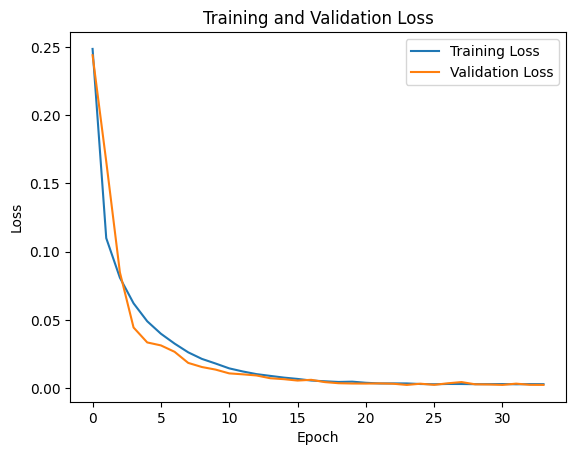

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.9072889953023264
MAE: 0.022170962489196467
RMSE: 0.041231760901778394
MSE: 0.0017000581070614215

--- Training round 3 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.3028 - val_loss: 0.2957
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1193 - val_loss: 0.1745
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0885 - val_loss: 0.0902
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0661 - val_loss: 0.0627
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0514 - val_loss: 0.0401
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0397 - val_loss: 0.0287
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0327 - val_loss: 0.0221
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0268 - val_loss: 0.0200
Epoch 9/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0226 - val_loss: 0.0153
Epoch 10/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0181 - val_loss: 0.0157
Epoch 11/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0163 - val_loss: 0.0111
Epoch 12/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss:

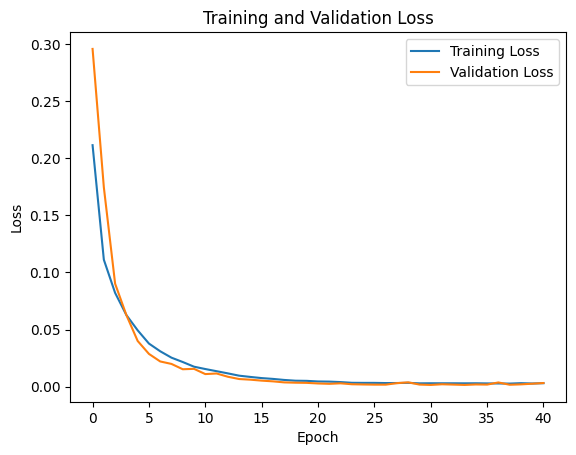

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R2: 0.8957280905101145
MAE: 0.016916020257520818
RMSE: 0.03611311126795801
MSE: 0.0013041568054519162


In [ ]:
models, metrics_gru = split_and_train_gru(X, y, look_back=7, num_splits=3, epochs=50, batch_size=16)

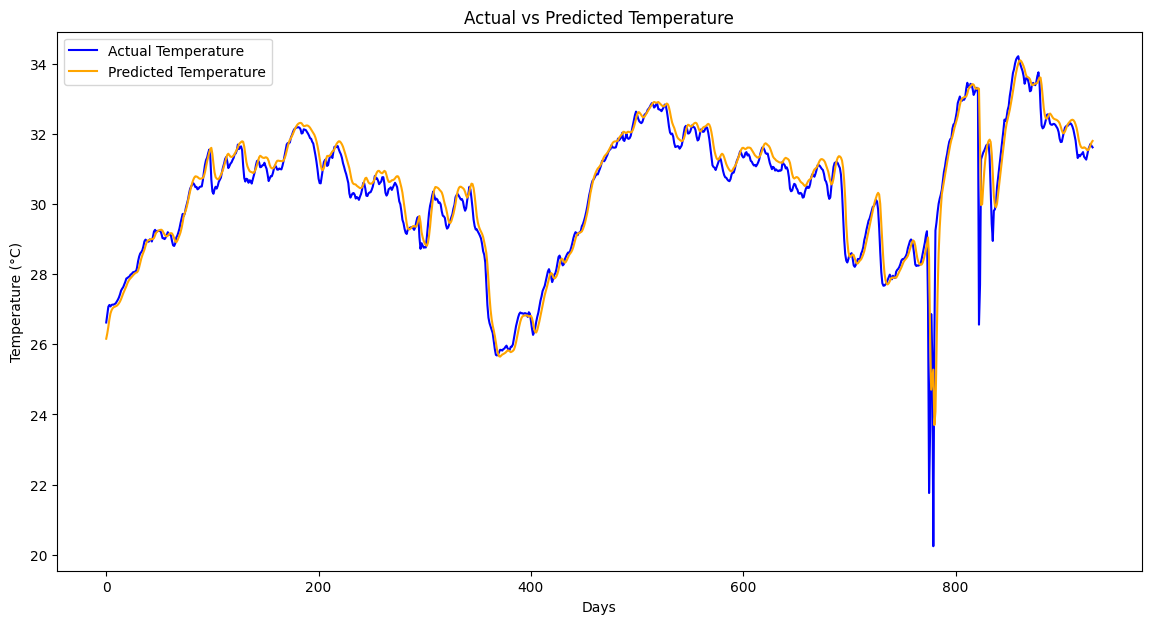

In [ ]:
# ตัวยอย่างค่าจริงและค่าทำนายจากโมเดลสุดท้าย
predictions_last_model = metrics_gru[-1]['predictions']
y_test_last_model = metrics_gru[-1]['y_test']

# แปลงค่าทำนายกลับไปยังหน่วยเดิม
predictions_last_model = scaler.inverse_transform(predictions_last_model)
y_test_last_model = scaler.inverse_transform(y_test_last_model.reshape(-1, 1))

# วาดกราฟ
plt.figure(figsize=(14, 7))
plt.plot(y_test_last_model, label='Actual Temperature', color='blue')
plt.plot(predictions_last_model, label='Predicted Temperature', color='orange')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


In [ ]:
predictions_last_model

array([[26.161627],
       [26.312922],
       [26.50341 ],
       [26.715748],
       [26.88266 ],
       [26.971651],
       [27.027208],
       [27.05979 ],
       [27.076118],
       [27.089218],
       [27.105045],
       [27.134344],
       [27.173742],
       [27.224693],
       [27.291285],
       [27.375137],
       [27.455225],
       [27.523676],
       [27.591833],
       [27.66498 ],
       [27.747608],
       [27.810122],
       [27.857918],
       [27.892895],
       [27.931458],
       [27.961363],
       [27.996378],
       [28.024864],
       [28.047586],
       [28.057243],
       [28.101582],
       [28.200676],
       [28.325909],
       [28.447714],
       [28.543545],
       [28.620275],
       [28.704206],
       [28.811922],
       [28.907734],
       [28.960705],
       [28.978735],
       [28.981329],
       [29.000465],
       [29.011866],
       [29.003819],
       [29.036804],
       [29.110523],
       [29.18633 ],
       [29.218962],
       [29.244228],


In [ ]:
y_test_last_model

array([[26.62495942],
       [26.85496894],
       [27.07528952],
       [27.12542304],
       [27.08298611],
       [27.12631944],
       [27.13520833],
       [27.13458333],
       [27.15270833],
       [27.17576389],
       [27.22888889],
       [27.27701389],
       [27.34284722],
       [27.43041667],
       [27.53493056],
       [27.59069444],
       [27.63486111],
       [27.70861111],
       [27.78923611],
       [27.884375  ],
       [27.89472222],
       [27.92506944],
       [27.94256944],
       [27.99673611],
       [28.00444444],
       [28.05527778],
       [28.06479167],
       [28.07888889],
       [28.06520833],
       [28.19041667],
       [28.37333333],
       [28.50506944],
       [28.59402778],
       [28.63305556],
       [28.68604167],
       [28.79576389],
       [28.94361111],
       [28.99131944],
       [28.96      ],
       [28.93631944],
       [28.93305556],
       [28.99833333],
       [28.98013889],
       [28.93756944],
       [29.07180556],
       [29

# **EC**

In [ ]:
def train_and_evaluate_gru(X_train, y_train, X_test, y_test, look_back, epochs=20, batch_size=16):
    # สร้างโมเดล GRU
    model = Sequential()

    # GRU ชั้นแรก พร้อม L2 Regularization และ Dropout
    model.add(GRU(50, return_sequences=True, input_shape=(look_back, 1),
                  kernel_regularizer=regularizers.l2(0.001)))  # L2 Regularization
    model.add(Dropout(0.25))

    # Batch Normalization หลังจาก GRU ชั้นแรก
    model.add(BatchNormalization())

    # GRU ชั้นที่สอง พร้อม L2 Regularization และ Dropout
    model.add(GRU(50, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.25))

    # Dense ชั้นที่มี Dropout
    model.add(Dense(20, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(1))  # Output layer
    optimizer = RMSprop(learning_rate=0.0005)
    model.compile(optimizer='adam', loss='mean_squared_error')

    # เพิ่ม EarlyStopping เพื่อตรวจจับการ overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop])

    # แสดงกราฟ Loss สำหรับ Training และ Validation
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")

    # เก็บค่า metrics ไว้ในดิกชันนารี
    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['Conductivity\n(uS/cm)']])

In [ ]:
look_back = 7
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [ ]:
data_scaled

array([[0.08649216],
       [0.08649216],
       [0.08649216],
       ...,
       [0.04477332],
       [0.04053825],
       [0.03188881]])


--- Training round 1 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0770 - val_loss: 0.0352
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0307 - val_loss: 0.0207
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0205 - val_loss: 0.0137
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0141 - val_loss: 0.0095
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0108 - val_loss: 0.0066
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0075 - val_loss: 0.0047
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0064 - val_loss: 0.0036
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0049 - val_loss: 0.0030
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0044 - val_loss: 0.0022
Epoch 10/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0037 - val_loss: 0.0018
Epoch 11/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033 - val_loss: 0.0015
Epoch 12/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/s

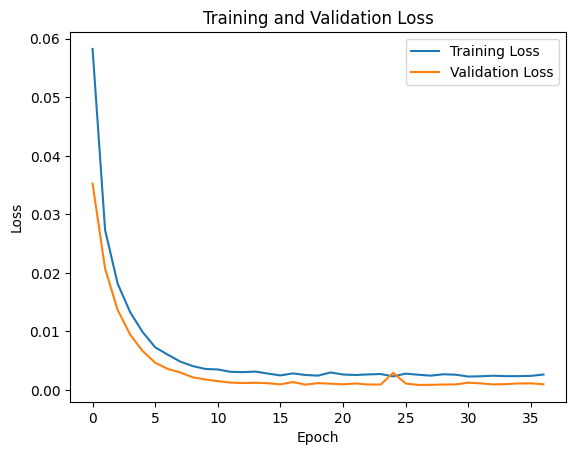

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.8546945328923893
MAE: 0.014324784741106005
RMSE: 0.022851436103722436
MSE: 0.0005221881320025092

--- Training round 2 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0897 - val_loss: 0.0393
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0379 - val_loss: 0.0258
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0259 - val_loss: 0.0185
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0189 - val_loss: 0.0133
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0151 - val_loss: 0.0100
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0130 - val_loss: 0.0077
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0094 - val_loss: 0.0063
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0081 - val_loss: 0.0050
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0068 - val_loss: 0.0036
Epoch 10/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0058 - val_loss: 0.0029
Epoch 11/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0049 - val_loss: 0.0025
Epoch 12/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/s

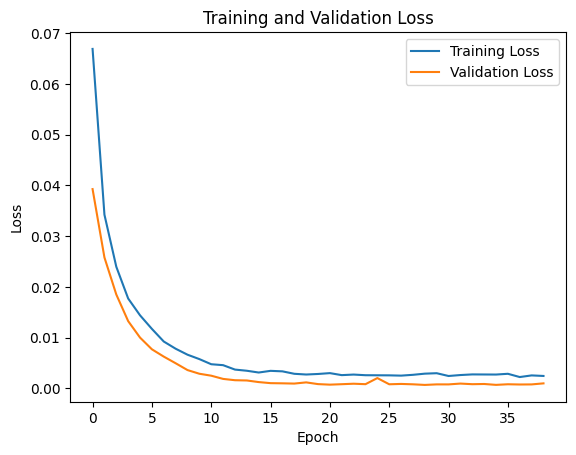

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R2: 0.8560461706564431
MAE: 0.012139787859514126
RMSE: 0.01822491607819375
MSE: 0.0003321475660572051

--- Training round 3 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


164/164 ━━━━━━━━━━━━━━━━━━━━ 63s 15ms/step - loss: 0.0972 - val_loss: 0.0401
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0405 - val_loss: 0.0271
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0276 - val_loss: 0.0203
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0219 - val_loss: 0.0153
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0182 - val_loss: 0.0119
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0141 - val_loss: 0.0099
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0123 - val_loss: 0.0079
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0104 - val_loss: 0.0063
Epoch 9/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0082 - val_loss: 0.0053
Epoch 10/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0071 - val_loss: 0.0042
Epoch 11/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0075 - val_loss: 0.0037
Epoch 12/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/s

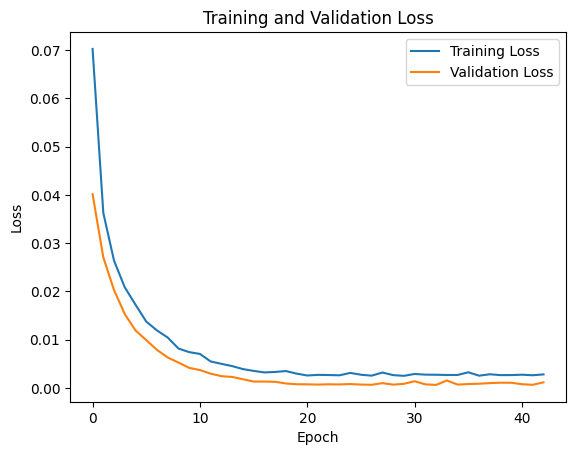

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.8690718300695904
MAE: 0.012380016618571141
RMSE: 0.018708039057914856
MSE: 0.0003499907253924677


In [ ]:
models, metrics_gru = split_and_train_gru(X, y, look_back=7, num_splits=3, epochs=100, batch_size=16)

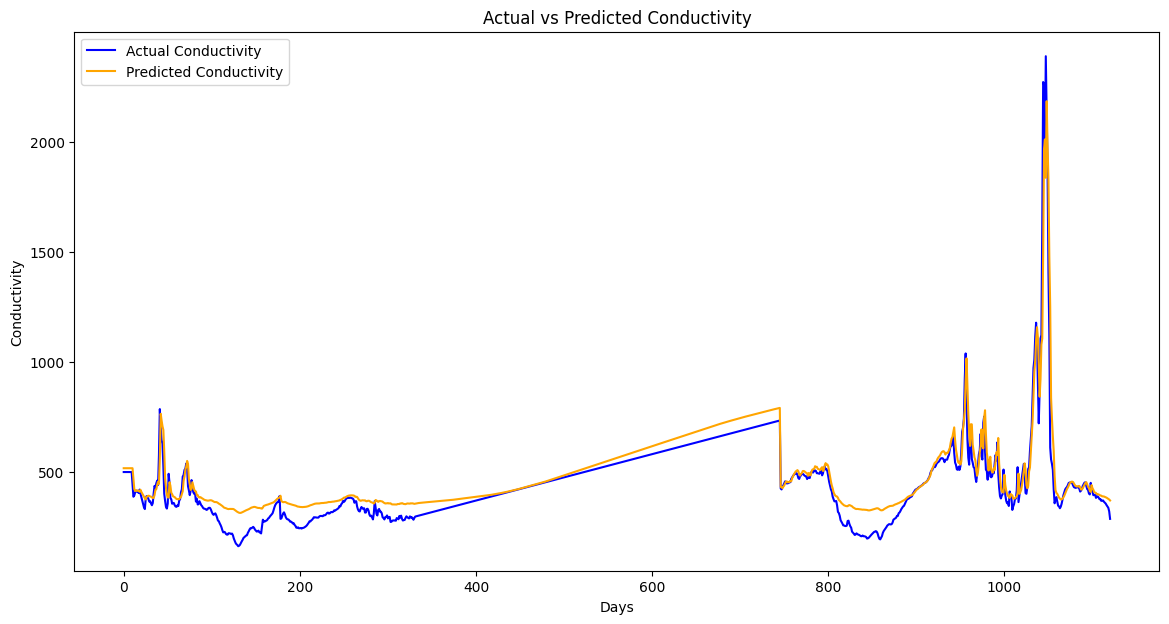

In [ ]:
predictions_last_model = metrics_gru[-1]['predictions']
y_test_last_model = metrics_gru[-1]['y_test']
predictions_last_model = scaler.inverse_transform(predictions_last_model)
y_test_last_model = scaler.inverse_transform(y_test_last_model.reshape(-1, 1))
plt.figure(figsize=(14, 7))
plt.plot(y_test_last_model, label='Actual Conductivity', color='blue')
plt.plot(predictions_last_model, label='Predicted Conductivity', color='orange')
plt.title('Actual vs Predicted Conductivity')
plt.xlabel('Days')
plt.ylabel('Conductivity')
plt.legend()
plt.show()

# **DO**

In [ ]:
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
def train_and_evaluate_gru(X_train, y_train, X_test, y_test, look_back, epochs=50, batch_size=16):

    model = Sequential()

    # GRU ชั้นแรก พร้อม L2 Regularization และ Dropout
    model.add(GRU(20, return_sequences=True, input_shape=(look_back, 1), kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.3))

    # Batch Normalization หลังจาก GRU ชั้นแรก
    model.add(BatchNormalization())

    # GRU ชั้นที่สอง พร้อม L2 Regularization และ Dropout
    model.add(GRU(20, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.3))

    # Dense ชั้นที่มี Dropout
    model.add(Dense(20, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.4))

    model.add(Dense(1))  # Output layer

    # ปรับค่า Learning Rate ของ Adam optimizer
    optimizer = RMSprop(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # เพิ่ม EarlyStopping และ Learning Rate Scheduling
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

    # ฝึกโมเดล
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop, reduce_lr])

    # แสดงกราฟ Loss สำหรับ Training และ Validation
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    # ทำการทำนาย
    predictions = model.predict(X_test)

    # คำนวณ metrics
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")

    # เก็บค่า metrics ไว้ในดิกชันนารี
    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df[['DO\n(mg/L)']])

In [ ]:
look_back = 7
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


--- Training round 1 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1494 - val_loss: 0.1391 - learning_rate: 5.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0894 - val_loss: 0.1123 - learning_rate: 5.0000e-04
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0647 - val_loss: 0.0906 - learning_rate: 5.0000e-04
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0524 - val_loss: 0.0742 - learning_rate: 5.0000e-04
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0436 - val_loss: 0.0614 - learning_rate: 5.0000e-04
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0359 - val_loss: 0.0463 - learning_rate: 5.0000e-04
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0290 - val_loss: 0.0383 - learning_rate: 5.0000e-04
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0243 - val_loss: 0.0280 - learning_rate: 5.0000e-04
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0212 - val_loss: 0.0208 - learning_rate: 5.000

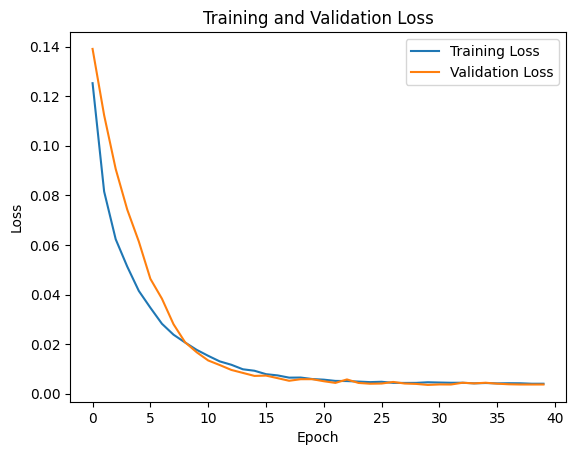

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.926687951588464
MAE: 0.03712366180934188
RMSE: 0.05208174690935636
MSE: 0.002712508361130251

--- Training round 2 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1611 - val_loss: 0.1623 - learning_rate: 5.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0925 - val_loss: 0.1391 - learning_rate: 5.0000e-04
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0679 - val_loss: 0.1066 - learning_rate: 5.0000e-04
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0521 - val_loss: 0.0867 - learning_rate: 5.0000e-04
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0436 - val_loss: 0.0691 - learning_rate: 5.0000e-04
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0350 - val_loss: 0.0606 - learning_rate: 5.0000e-04
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0287 - val_loss: 0.0404 - learning_rate: 5.0000e-04
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0245 - val_loss: 0.0380 - learning_rate: 5.0000e-04
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0214 - val_loss: 0.0263 - learning_rate: 5.0

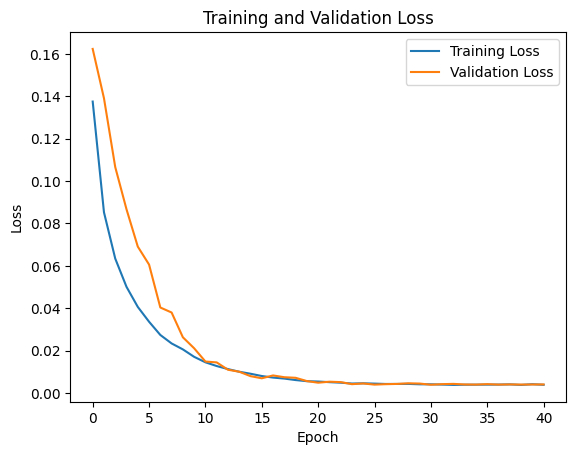

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.913461970040322
MAE: 0.040093822329861376
RMSE: 0.05601978937982981
MSE: 0.003138216802160492

--- Training round 3 ---
Training data size: (2614, 7, 1), Testing data size: (1121, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3791 - val_loss: 0.1379 - learning_rate: 5.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1048 - val_loss: 0.1065 - learning_rate: 5.0000e-04
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0656 - val_loss: 0.0918 - learning_rate: 5.0000e-04
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0507 - val_loss: 0.0687 - learning_rate: 5.0000e-04
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0399 - val_loss: 0.0555 - learning_rate: 5.0000e-04
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0325 - val_loss: 0.0460 - learning_rate: 5.0000e-04
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0272 - val_loss: 0.0317 - learning_rate: 5.0000e-04
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0227 - val_loss: 0.0264 - learning_rate: 5.0000e-04
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0184 - val_loss: 0.0164 - learning_rate: 5.0

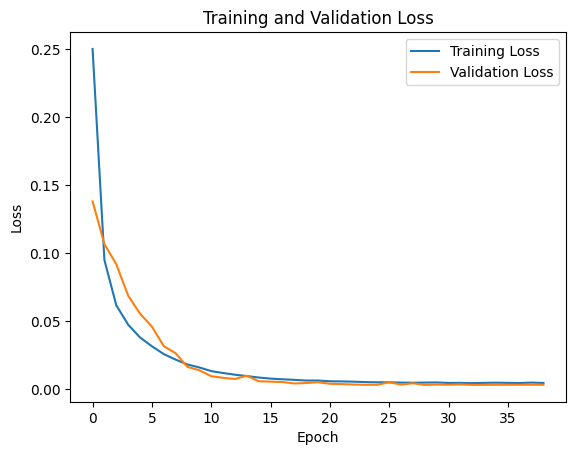

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
R2: 0.9017782708944572
MAE: 0.029355965948505126
RMSE: 0.04782354006381178
MSE: 0.0022870909842350106


In [ ]:
models, metrics_gru = split_and_train_gru(X, y, look_back=7, num_splits=3, epochs=100, batch_size=32)

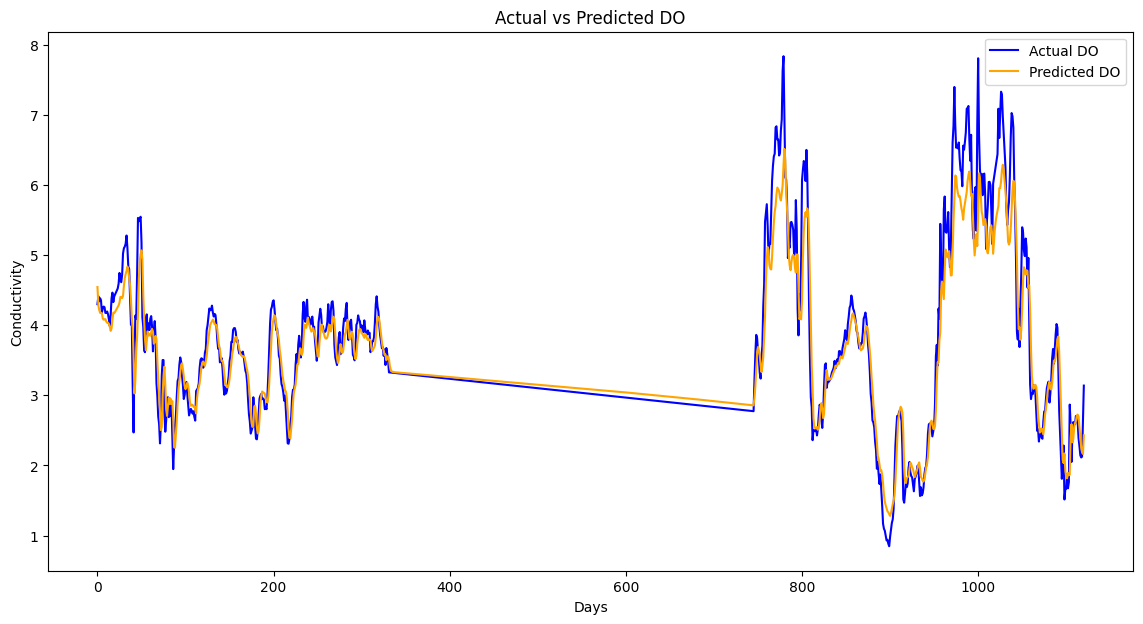

In [ ]:
import matplotlib.pyplot as plt
predictions_last_model = metrics_gru[-1]['predictions']
y_test_last_model = metrics_gru[-1]['y_test']
predictions_last_model = scaler.inverse_transform(predictions_last_model)
y_test_last_model = scaler.inverse_transform(y_test_last_model.reshape(-1, 1))
plt.figure(figsize=(14, 7))
plt.plot(y_test_last_model, label='Actual DO', color='blue')
plt.plot(predictions_last_model, label='Predicted DO', color='orange')
plt.title('Actual vs Predicted DO')
plt.xlabel('Days')
plt.ylabel('Conductivity')
plt.legend()
plt.show()

# **pH**

In [ ]:
df['pH']

,pH
date_time,
2014-04-28,9.276510
2014-04-29,9.045638
2014-04-30,8.713181
2014-05-01,8.380725
2014-05-02,8.048268
...,...
2024-07-21,3.080000
2024-07-22,3.080000
2024-07-23,3.080000


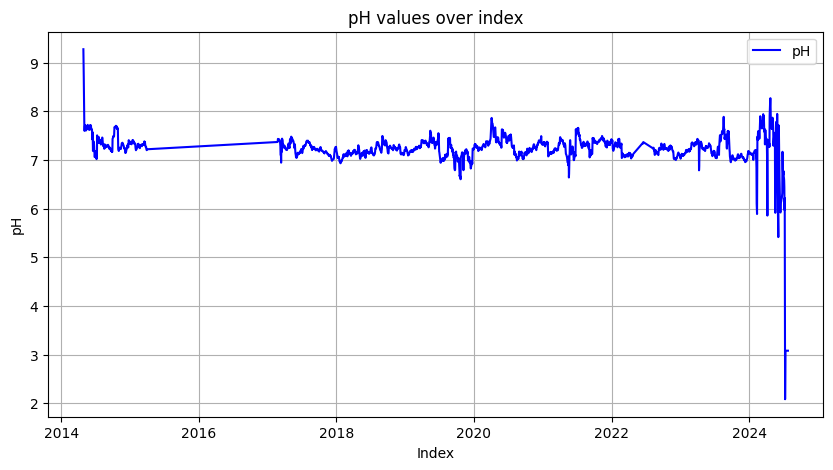

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['pH'], label='pH', color='blue')
plt.title('pH values over index')
plt.xlabel('Index')
plt.ylabel('pH')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
ph_2024 = df.loc['2024-01-01':'2024-12-31', 'pH']

In [ ]:
ph_2024

,pH
date_time,
2024-01-01,7.147083
2024-01-02,7.136042
2024-01-03,7.132778
2024-01-04,7.140486
2024-01-05,7.155625
...,...
2024-07-21,3.080000
2024-07-22,3.080000
2024-07-23,3.080000


In [ ]:
ph_2024.value_counts()

,count
pH,
3.080000,14
7.147083,1
7.132778,1
7.140486,1
7.155625,1
...,...
6.432639,1
6.217419,1
4.419900,1


In [ ]:
df_filtered = df[df['pH'] >= 4]

In [ ]:
df_filtered.describe()

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,3726.000000,3726.000000,3726.000000,3726.000000
mean,30.077333,501.800822,2.966926,7.254912
std,1.605338,360.000706,1.114613,0.205745
min,20.238053,164.506944,0.233403,4.419900
25%,29.152187,318.136576,2.333420,7.162153
50%,30.198879,386.746528,2.910165,7.262303
75%,31.237439,541.338542,3.472274,7.340608
max,34.226458,4057.263889,7.837917,9.276510


In [ ]:
df_filtered

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
date_time,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510
2014-04-29,29.433154,501.199898,7.346309,9.045638
2014-04-30,30.001423,501.199898,6.754846,8.713181
2014-05-01,30.569691,501.199898,6.163383,8.380725
2014-05-02,31.137960,501.199898,5.571919,8.048268
...,...,...,...,...
2024-07-05,31.274931,412.486111,1.668333,6.579583
2024-07-06,31.412986,396.027778,1.876875,6.432639
2024-07-07,31.568542,397.638889,1.674931,5.970347


In [ ]:
def train_and_evaluate_gru(X_train, y_train, X_test, y_test, look_back, epochs=20, batch_size=16):
    # สร้างโมเดล GRU
    model = Sequential()

    # GRU ชั้นแรก พร้อม L2 Regularization และ Dropout
    model.add(GRU(50, return_sequences=True, input_shape=(look_back, 1),
                  kernel_regularizer=regularizers.l2(0.00001)))  # L2 Regularization
    model.add(Dropout(0.25))

    # Batch Normalization หลังจาก GRU ชั้นแรก
    model.add(BatchNormalization())

    # GRU ชั้นที่สอง พร้อม L2 Regularization และ Dropout
    model.add(GRU(50, return_sequences=False, kernel_regularizer=regularizers.l2(0.00001)))
    model.add(Dropout(0.25))

    # Dense ชั้นที่มี Dropout
    model.add(Dense(20, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(1))  # Output layer
    optimizer = RMSprop(learning_rate=0.00001)
    model.compile(optimizer='adam', loss='mean_squared_error')

    # เพิ่ม EarlyStopping เพื่อตรวจจับการ overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_test, y_test), callbacks=[early_stop])

    # แสดงกราฟ Loss สำหรับ Training และ Validation
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"MSE: {mse}")

    # เก็บค่า metrics ไว้ในดิกชันนารี
    metrics = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'predictions': predictions,
        'y_test': y_test
    }

    return model, predictions, metrics

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df_filtered[['pH']])

In [ ]:
data_scaled

array([[1.        ],
       [0.95246221],
       [0.8840078 ],
       ...,
       [0.31924468],
       [0.37011809],
       [0.        ]])

In [ ]:
look_back = 7
X, y = create_dataset(data_scaled, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [ ]:
X

array([[[1.        ],
        [0.95246221],
        [0.8840078 ],
        ...,
        [0.74709897],
        [0.6777917 ],
        [0.6543693 ]],

       [[0.95246221],
        [0.8840078 ],
        [0.81555338],
        ...,
        [0.6777917 ],
        [0.6543693 ],
        [0.65891637]],

       [[0.8840078 ],
        [0.81555338],
        [0.74709897],
        ...,
        [0.6543693 ],
        [0.65891637],
        [0.67410901]],

       ...,

       [[0.47007007],
        [0.47042754],
        [0.48392575],
        ...,
        [0.45518485],
        [0.44468942],
        [0.41443283]],

       [[0.47042754],
        [0.48392575],
        [0.45880249],
        ...,
        [0.44468942],
        [0.41443283],
        [0.31924468]],

       [[0.48392575],
        [0.45880249],
        [0.45518485],
        ...,
        [0.41443283],
        [0.31924468],
        [0.37011809]]])


--- Training round 1 ---
Training data size: (2603, 7, 1), Testing data size: (1116, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1093 - val_loss: 0.1551
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0276 - val_loss: 0.0963
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0188 - val_loss: 0.0538
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0138 - val_loss: 0.0301
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0105 - val_loss: 0.0233
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0091 - val_loss: 0.0116
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0074 - val_loss: 0.0070
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0061 - val_loss: 0.0036
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0057 - val_loss: 0.0042
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0049 - val_loss: 0.0027
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0043 - val_loss: 0.0032
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0037 - va

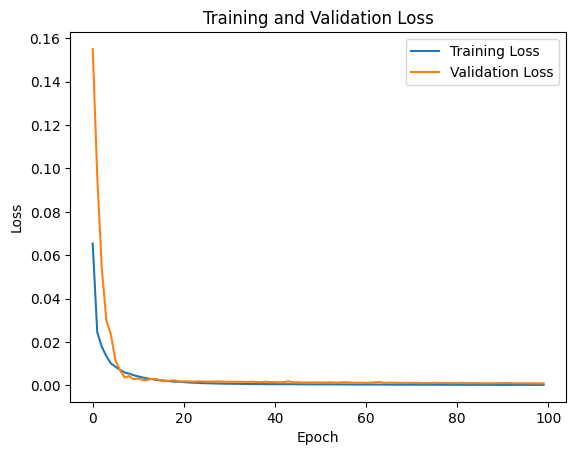

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.7592212867664506
MAE: 0.010465323510662348
RMSE: 0.029214969010111225
MSE: 0.0008535144142617592

--- Training round 2 ---
Training data size: (2603, 7, 1), Testing data size: (1116, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1080 - val_loss: 0.1584
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0317 - val_loss: 0.1075
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0198 - val_loss: 0.0626
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0146 - val_loss: 0.0373
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0119 - val_loss: 0.0214
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0092 - val_loss: 0.0106
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0077 - val_loss: 0.0080
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0064 - val_loss: 0.0041
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0057 - val_loss: 0.0030
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0050 - val_loss: 0.0025
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val

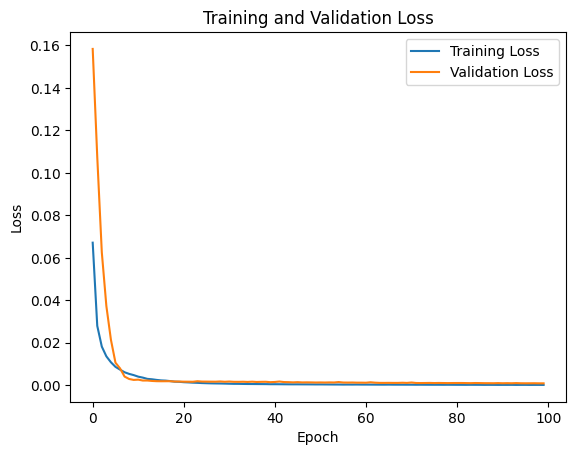

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
R2: 0.7670636911213309
MAE: 0.011471737734523441
RMSE: 0.029675681931531504
MSE: 0.0008806460981014254

--- Training round 3 ---
Training data size: (2603, 7, 1), Testing data size: (1116, 7, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 60s 13ms/step - loss: 0.0950 - val_loss: 0.1564
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0290 - val_loss: 0.0962
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0179 - val_loss: 0.0721
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0145 - val_loss: 0.0379
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0103 - val_loss: 0.0266
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0086 - val_loss: 0.0187
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0075 - val_loss: 0.0052
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0059 - val_loss: 0.0043
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0049 - val_loss: 0.0028
Epoch 10/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0041 - val_loss: 0.0027
Epoch 11/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037 - val_loss: 0.0029
Epoch 12/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0033 -

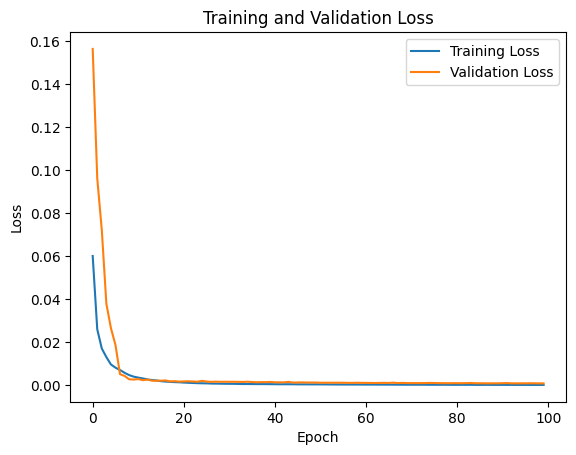

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
R2: 0.7666133803932065
MAE: 0.010571492692504077
RMSE: 0.02913528925202012
MSE: 0.0008488650797988791


In [ ]:
models, metrics_gru = split_and_train_gru(X, y, look_back=7, num_splits=3, epochs=100, batch_size=32)

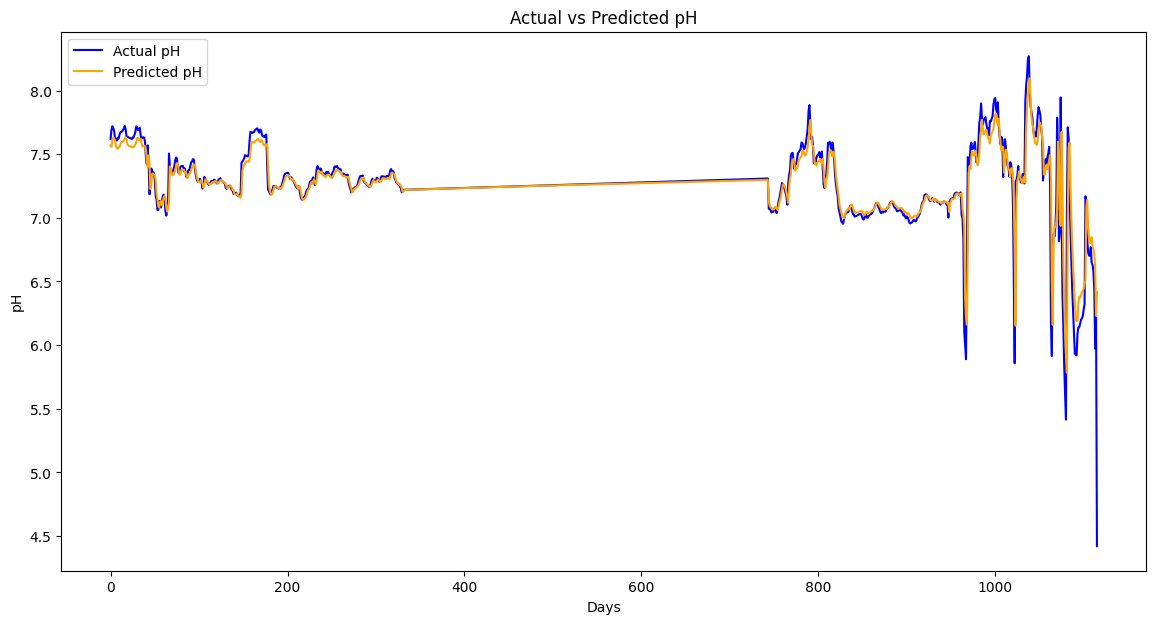

In [ ]:
# ตัวยอย่างค่าจริงและค่าทำนายจากโมเดลสุดท้าย
predictions_last_model = metrics_gru[-1]['predictions']
y_test_last_model = metrics_gru[-1]['y_test']
predictions_last_model = predictions_last_model.reshape(-1, 1)
y_test_last_model = y_test_last_model.reshape(-1, 1)
predictions_last_model = scaler.inverse_transform(predictions_last_model)
y_test_last_model = scaler.inverse_transform(y_test_last_model)
plt.figure(figsize=(14, 7))
plt.plot(y_test_last_model, label='Actual pH', color='blue')
plt.plot(predictions_last_model, label='Predicted pH', color='orange')
plt.title('Actual vs Predicted pH')
plt.xlabel('Days')
plt.ylabel('pH')
plt.legend()
plt.show()
